<a href="https://colab.research.google.com/github/djdhawal/bayesian-failure-prediction-on-cluster-traces/blob/main/notebooks/task_hmm_v02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# load the drive helper and mount
from google.colab import drive

# this will prompt for authorization. Please Accept the auth request
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Bayesian Final Project/DATA"
## now you should be able to see the drive folder accessible by collab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install funsor

In [3]:
pip install numpyro

In [4]:
import pandas as pd
import numpy as np
import jax.numpy as jnp
from jax import random

import numpyro
import numpyro.distributions as dist
from numpyro import util
from numpyro.contrib.control_flow import scan
from numpyro.infer import SVI, TraceEnum_ELBO, init_to_median, Predictive
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import optax_to_numpyro

import optax
from numpyro import handlers
from scipy.stats import norm, f_oneway

import ast
import regex as re

from scipy.special import logsumexp
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

import os
import pyarrow.parquet as pq

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [5]:
path = "/content/drive/MyDrive/Bayesian Final Project/DATA"
df = pd.read_parquet(f"{path}/instance_usage_training01_parquet.parquet")

In [6]:
# dropping duplicates for instance_usage
df = df.drop_duplicates(
    subset=["collection_id", "instance_index", "start_time"],
    keep="first"
)

In [7]:
instance_events = os.path.join(path, "instance_events_training01_parquet.parquet")

instance_events_pf = pq.ParquetFile(instance_events)
print(instance_events_pf.schema)

required group field_id=-1 schema {
  optional int64 field_id=-1 collection_id;
  optional int64 field_id=-1 instance_index;
  optional int64 field_id=-1 time;
  optional int64 field_id=-1 type;
}



Reads a Parquet file efficiently using batch iteration, optionally limiting the number of rows loaded to avoid high memory usage when working with large datasets.

In [8]:
def read_parquet_dotted(path, columns, nrows=None, batch_size=200_000):
    # path: location of the parquet file
    # columns: list of column names to load (to avoid reading unnecessary columns)
    # nrows: optional limit on number of rows to load
    # batch_size: how many rows to read at a time when streaming the file

    pf = pq.ParquetFile(path)
    # if row limit isn't there, we read the dataset normally
    if nrows is None:
        tbl = pf.read(columns=columns)
        return tbl.to_pandas()

    out = []
    total = 0
    for batch in pf.iter_batches(batch_size=batch_size, columns=columns):
        chunk = batch.to_pandas()
        out.append(chunk)
        total += len(chunk)
        if total >= nrows:
            break
    df = pd.concat(out, ignore_index=True)
    return df.iloc[:nrows].copy()

In [9]:
instance_events_df = read_parquet_dotted(instance_events, None)

In [10]:
# duplication check for instance_events
instance_events_df = instance_events_df.drop_duplicates(
    subset=["collection_id", "instance_index", "time"],
    keep="first"
)

### Downcasting to save memory

In [11]:
instance_events_df["collection_id"] = pd.to_numeric(instance_events_df["collection_id"], downcast="integer")
instance_events_df["instance_index"] = pd.to_numeric(instance_events_df["instance_index"], downcast="integer")
instance_events_df["type"] = pd.to_numeric(instance_events_df["type"], downcast="integer")
instance_events_df["time"] = pd.to_numeric(instance_events_df["time"], downcast="integer")

In [12]:
instance_events_df.head()

,collection_id,instance_index,time,type
0,330587125888,13,2305877675138,0
1,330587125888,406,2337139488043,0
2,330587125888,696,1902747071586,0
3,330587125888,265,1280003584881,0
4,330587125888,557,1852008055701,0


In [13]:
# merging based on last_event being one of the 2 below aka fail, kill
FAIL_TYPES = {5, 7}  # fail, kill (removed 4 aka evict)

instance_events_df["time"] = pd.to_numeric(instance_events_df["time"], errors="coerce")

# last event row per (collection_id, instance_index)
last_rows = instance_events_df.loc[
    instance_events_df.groupby(["collection_id", "instance_index"])["time"].idxmax(),
    ["collection_id", "instance_index", "type"]
].copy()

last_rows["last_event"] = last_rows["type"].isin(FAIL_TYPES).astype("int8")

# merge/broadcast onto df
df = df.merge(
    last_rows[["collection_id", "instance_index", "last_event"]],
    on=["collection_id", "instance_index"],
    how="left"
)

df["last_event"] = df["last_event"].fillna(0).astype("int8")

In [14]:
df.head()

,start_time,collection_id,instance_index,average_usage_cpus,average_usage_memory,maximum_usage_cpus,maximum_usage_memory,cycles_per_instruction,random_sample_usage_cpus,random_sample_usage_memory,assigned_memory,page_cache_memory,memory_accesses_per_instruction,cpu_usage_distribution,tail_cpu_usage_distribution,last_event
0,1704900000000,9941075899,8,0.009247,1.756668e-03,0.028259,1.766205e-03,2.737086,0.007271,NaN,0.000000,0.000143,0.006497,"[0.00556182861328125, 0.00688934326171875, 0.0...","[0.0131988525390625, 0.0132904052734375, 0.013...",0
1,2061900000000,9941075899,8,0.006569,1.771927e-03,0.022339,1.783371e-03,3.101036,0.006004,NaN,0.000000,0.000147,0.007710,"[0.00493621826171875, 0.00568389892578125, 0.0...","[0.00732421875, 0.00743865966796875, 0.0078125...",0
2,307200000000,19542402683,12,0.001299,1.531601e-03,0.012695,1.798630e-03,1.701610,0.000281,NaN,0.001953,0.000058,0.008485,"[0.00019359588623046875, 0.0002117156982421875...","[0.004913330078125, 0.0050048828125, 0.0051498...",0
3,166614000000,84700535897,0,0.001465,7.057190e-05,0.003113,1.316071e-04,NaN,0.002598,NaN,0.000185,0.000070,NaN,"[3.719329833984375e-05, 3.719329833984375e-05,...","[0.002979278564453125, 0.002979278564453125, 0...",0
4,346323000000,84700535897,0,0.000000,9.536743e-07,0.000000,9.536743e-07,NaN,0.000000,NaN,0.000177,0.000000,NaN,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0


Parses CPU usage distribution fields (strings, lists, or arrays) into a fixed-length numeric vector of percentile values, padding with NaNs when data is missing or malformed.

In [15]:
def parse_dist(val, expected_len=11):
    # Define a function that parses a CPU distribution field into numeric values.
    # val: the raw value coming from the dataset (can be list, numpy array, or string).
    # expected_len: the number of values we expect in the distribution (default = 11 percentiles).
    try:
        if isinstance(val, (list, np.ndarray)):
            vals = list(val)
        elif isinstance(val, str):
            nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', val)
            vals = [float(x) for x in nums]
        else:
            return [np.nan] * expected_len
        return vals[:expected_len] + [np.nan] * max(0, expected_len - len(vals))
    except:
        return [np.nan] * expected_len

Expands the CPU usage distribution column into individual percentile features (p0–p100) and engineers a burstiness metric to capture variability in CPU usage.

In [16]:
def clean_cpu_usage_distribution(df):
    # Define a function that cleans and expands the "cpu_usage_distribution" column in a DataFrame.
    # df: pandas DataFrame containing a column called "cpu_usage_distribution"
    # which stores CPU usage percentile distributions.
    # Result:
    # dist_parsed becomes a pandas Series where each element is a list like:
    # [p0, p10, p20, ..., p100]
    dist_parsed = df["cpu_usage_distribution"].apply(parse_dist)
    pct_cols = [f"cpu_p{i}" for i in range(0, 101, 10)]

    dist_df = pd.DataFrame(dist_parsed.tolist(), columns=pct_cols)
    df[pct_cols] = dist_df
    df["cpu_burstiness"] = df["cpu_p90"] - df["cpu_p10"]
    return df

Extracts statistical features from the tail CPU usage distribution, including mean, max, 90th percentile, and the fraction of non-zero usage to characterize high-end CPU behavior.

In [17]:
def extract_tail_cpu_features(df):
    # Define a function that extracts statistical features from the
    # "tail_cpu_usage_distribution" column in a DataFrame.

    # df: pandas DataFrame containing tail CPU usage distributions
    #     (usually percentiles or histogram-like values).

    # earlier, using parse_dist we converted the distribution into a numeric list
    # we now compute summary stats from those values
    def get_stats(arr):
        arr = np.array(arr)
        clean = arr[~np.isnan(arr)]
        if len(clean)==0:
            return [np.nan]*4
        return [
            np.mean(clean),
            np.max(clean),
            np.percentile(clean, 90),
            np.mean(clean>0)
        ]

    tail_parsed = df["tail_cpu_usage_distribution"].apply(
        lambda x: get_stats(parse_dist(x, expected_len=9))
    )

    df[['tail_cpu_mean',
        'tail_cpu_max',
        'tail_cpu_p90',
        'tail_cpu_nonzero_frac']] = pd.DataFrame(tail_parsed.tolist())

    return df

In [18]:
df = clean_cpu_usage_distribution(df)
df = extract_tail_cpu_features(df)

Matches “kill” events from `instance_events_df` to the nearest preceding rows in `df` based on `collection_id`, `instance_index`, and `time`, marking those rows with a `kill_row` flag for downstream analysis.

In [19]:
# copy df and initialize new column
df["kill_row"] = 0

# make sure key/time types match
df["collection_id"] = df["collection_id"].astype("int64")
df["instance_index"] = df["instance_index"].astype("int64")
df["start_time"] = df["start_time"].astype("int64")

instance_events_df = instance_events_df.copy()
instance_events_df["collection_id"] = instance_events_df["collection_id"].astype("int64")
instance_events_df["instance_index"] = instance_events_df["instance_index"].astype("int64")
instance_events_df["time"] = instance_events_df["time"].astype("int64")
instance_events_df["type"] = instance_events_df["type"].astype("int64")

# keep only kill events
kill_events = instance_events_df[
    instance_events_df["type"].isin([5, 7])
][["collection_id", "instance_index", "time"]].copy()

# preserve original row index from df
df_work = df.reset_index().rename(columns={"index": "orig_index"})

matched_indices = []

# loop through each (collection_id, instance_index) pair that has kill events
for (cid, iid), kills_g in kill_events.groupby(["collection_id", "instance_index"]):

    df_g = df_work[
        (df_work["collection_id"] == cid) &
        (df_work["instance_index"] == iid)
    ][["orig_index", "collection_id", "instance_index", "start_time"]].copy()

    # if no rows in df for this pair, skip
    if df_g.empty:
        continue

    # sort within this one pair
    df_g = df_g.sort_values("start_time").reset_index(drop=True)
    kills_g = kills_g.sort_values("time").reset_index(drop=True)

    # nearest earlier row only
    matched_g = pd.merge_asof(
        kills_g,
        df_g,
        left_on="time",
        right_on="start_time",
        direction="backward"
    )

    # keep successful matches
    idx = matched_g["orig_index"].dropna().astype(int).tolist()
    matched_indices.extend(idx)

# mark matched rows
df.loc[np.unique(matched_indices), "kill_row"] = 1

Computes log-normalization parameters (mean, standard deviation, and epsilon) for specified columns using only the training data

In [20]:
# fitting normalization parameters (TRAIN ONLY)
def fit_log_norm(df, cols, eps=1e-7):
    params = {}
    for col in cols:
        x = df[col].astype(float)
        x_logged = np.log(x + eps)
        mu = x_logged.mean()
        sigma = x_logged.std()
        if sigma < 1e-8:
            sigma = 1e-8

        params[col] = {
            "eps": eps,
            "mean": mu,
            "std": sigma
        }
    return params

Applies log-normalization to specified columns using precomputed training parameters, creating both logged and standardized (zero-mean, unit-variance) features for train and test datasets.

In [21]:
# apply normalization TRAIN + TEST
def apply_log_norm(df, cols, params):
    for col in cols:
        eps = params[col]["eps"]
        mu = params[col]["mean"]
        sigma = params[col]["std"]

        x = df[col].astype(float)
        df[f"{col}_logged"] = np.log(x + eps)
        df[f"{col}_logged_normed"] = (df[f"{col}_logged"] - mu) / sigma

    return df

In [22]:
df.columns

Index(['start_time', 'collection_id', 'instance_index', 'average_usage_cpus',
       'average_usage_memory', 'maximum_usage_cpus', 'maximum_usage_memory',
       'cycles_per_instruction', 'random_sample_usage_cpus',
       'random_sample_usage_memory', 'assigned_memory', 'page_cache_memory',
       'memory_accesses_per_instruction', 'cpu_usage_distribution',
       'tail_cpu_usage_distribution', 'last_event', 'cpu_p0', 'cpu_p10',
       'cpu_p20', 'cpu_p30', 'cpu_p40', 'cpu_p50', 'cpu_p60', 'cpu_p70',
       'cpu_p80', 'cpu_p90', 'cpu_p100', 'cpu_burstiness', 'tail_cpu_mean',
       'tail_cpu_max', 'tail_cpu_p90', 'tail_cpu_nonzero_frac', 'kill_row'],
      dtype='object')

Unique pairs (collection_id, instance_index) for each `last_event` category

In [23]:
pair_counts = (
    df.drop_duplicates(subset=["collection_id", "instance_index"])
      .groupby("last_event")
      .size()
)

print(pair_counts)

last_event
0    765
1    140
dtype: int64


Splits unique (collection_id, instance_index) pairs into train and test sets using a stratified 80/20 split based on the `last_event` label to preserve class distribution.

In [24]:
# Splitting train test (stratified based on last_event as evict/kill/fail)

pairs = df[["collection_id","instance_index","last_event"]].drop_duplicates()

train_pairs, test_pairs = train_test_split(
    pairs,
    test_size=0.2,
    stratify=pairs["last_event"],
    random_state=42
)

In [25]:
# applying back onto our actual df
train_df = df.merge(
    train_pairs[["collection_id","instance_index"]],
    on=["collection_id","instance_index"],
    how="inner"
)

test_df = df.merge(
    test_pairs[["collection_id","instance_index"]],
    on=["collection_id","instance_index"],
    how="inner"
)

In [26]:
# checking for any overlap, set() confirms there's 0 overlap
set(train_pairs.apply(tuple,axis=1)).intersection(
    set(test_pairs.apply(tuple,axis=1))
)

set()

In [27]:
# verifying the split
train_pairs['last_event'].value_counts(), test_pairs['last_event'].value_counts()

(last_event
 0    612
 1    112
 Name: count, dtype: int64,
 last_event
 0    153
 1     28
 Name: count, dtype: int64)

In [28]:
cols_to_normalize = [
    'average_usage_cpus',
    'average_usage_memory',
    'maximum_usage_cpus',
    'maximum_usage_memory',
    'assigned_memory',
    'page_cache_memory',
    'cpu_p50',
    'cpu_p90',
    'cpu_p100',
    'cpu_burstiness',
    'tail_cpu_mean'
]

# filling na values
train_df[cols_to_normalize] = train_df[cols_to_normalize].fillna(0.0)
test_df[cols_to_normalize] = test_df[cols_to_normalize].fillna(0.0)

Fits log-normalization parameters on the training set and applies log-scaling and standardization to both train and test datasets using those parameters.

In [29]:
norm_params = fit_log_norm(train_df, cols_to_normalize)

train_df = apply_log_norm(train_df, cols_to_normalize, norm_params)
test_df = apply_log_norm(test_df, cols_to_normalize, norm_params)

In [30]:
norm_params_path = "/content/drive/MyDrive/Bayesian Final Project/DATA/norm_params.pkl"

with open(norm_params_path, "wb") as f:
    pickle.dump(norm_params, f)

In [31]:
candidate_feature_set = [f"{c}_logged_normed" for c in cols_to_normalize]

Defines the final set of normalized features (log-transformed and standardized) to be used as input for modeling

In [32]:
# final feature set
feature_set = ['average_usage_cpus_logged_normed', 'cpu_p90_logged_normed', 'average_usage_memory_logged_normed', 'assigned_memory_logged_normed', 'cpu_burstiness_logged_normed']

Builds time-ordered feature sequences for each job, with optional truncation, ready for padding to equal lengths for model input

In [33]:
def build_job_sequences_ragged(df, feature_cols, time_col="start_time", max_T=None):
    # df: pandas DataFrame with job/event data
    # feature_cols: list of columns to include in each sequence
    # time_col: column used to sort events chronologically
    # max_T: optional maximum sequence length
    # Returns: list of sequences (NumPy arrays), array of lengths, and list of (collection_id, instance_index) keys

    seqs, lengths, keys = [], [], []
    for (cid, iid), g in df.groupby(["collection_id", "instance_index"], sort=True):
        g = g.sort_values(time_col)
        X = g[feature_cols].to_numpy(dtype=np.float32)
        if max_T is not None and X.shape[0] > max_T:
            X = X[:max_T]
        # Truncate sequence if it exceeds max_T
        if X.shape[0] == 0:
            continue
        seqs.append(X)
        lengths.append(X.shape[0])
        keys.append((cid, iid))
    return seqs, np.array(lengths, dtype=np.int32), keys

Pads a batch of variable-length sequences to a fixed length (Tmax_fixed) for model input, keeping track of original sequence lengths

In [34]:
def make_batch_fixed_T(seqs_list, lengths, idx, Tmax_fixed):
    # seqs_list: list of sequences (NumPy arrays) of varying lengths
    # lengths: array of original sequence lengths
    # idx: indices of sequences to include in this batch
    # Tmax_fixed: fixed sequence length for padding
    # Returns: padded batch array (B, Tmax_fixed, D) and lengths array
    idx = np.asarray(idx, dtype=int)
    B = len(idx)
    D = seqs_list[idx[0]].shape[1]

    X = np.zeros((B, Tmax_fixed, D), dtype=np.float32)
    # initialize batch array with zeros for padding
    L = np.zeros((B,), dtype=np.int32)

    for i, j in enumerate(idx):
        xj = seqs_list[j]
        T = min(xj.shape[0], Tmax_fixed)
        X[i, :T, :] = xj[:T]
        L[i] = T

    # return JAX arrays for model input
    return jnp.asarray(X), jnp.asarray(L)

Defines a Gaussian Hidden Markov Model (HMM) over sequences, with K latent states, modeling observations as state-dependent multivariate Gaussians.

In [35]:
def gaussian_hmm_model(seqs, lengths, K=3):
    # seqs: batch of sequences (B, Tmax, D)
    # lengths: array of actual sequence lengths
    # K: number of hidden states
    # B: batch size, Tmax: max sequence length, D: feature dimension
    B, Tmax, D = seqs.shape

    # Initial state probabilities, each state has an equal chance
    pi = numpyro.sample("pi", dist.Dirichlet(jnp.ones(K)))
    A  = numpyro.sample("A", dist.Dirichlet(jnp.ones(K)).expand([K]).to_event(1))

    # Gaussian observation parameters per state
    mu    = numpyro.sample("mu", dist.Normal(0, 1).expand([K, D]).to_event(2))
    sigma = numpyro.sample("sigma", dist.Exponential(1.0).expand([K, D]).to_event(2))

    # Sample initial latent states for each sequence
    with numpyro.plate("seq", B):
        z_prev = numpyro.sample(
            "z_0",
            dist.Categorical(pi),
            infer={"enumerate": "parallel"}
        )

    # Iterate over each time step
    for t in range(Tmax):
        mask_t = lengths > t  # (B,)

        with numpyro.plate("seq", B):
            # Sample latent state at time t+1 conditioned on previous state
            z_t = numpyro.sample(
                f"z_{t+1}",
                dist.Categorical(A[z_prev]),
                infer={"enumerate": "parallel"}
            )

            # Observe sequence features with masking for shorter sequences
            with numpyro.handlers.mask(mask=mask_t):
                numpyro.sample(
                    f"x_{t}",
                    dist.Normal(mu[z_t], sigma[z_t]).to_event(1),
                    obs=seqs[:, t, :]
                )

        z_prev = z_t # update previous state for next time step



Sets up Stochastic Variational Inference (SVI) for the Gaussian HMM, hiding discrete latent states from optimization and using an adaptive Adam optimizer with gradient clipping.

In [36]:
def hide_discrete(msg):
    name = msg.get("name", "")
    return name.startswith("z_")  # hides z_0, z_1, ...

# Block discrete latent states from the guide
blocked = handlers.block(gaussian_hmm_model, hide_fn=hide_discrete)

# Define variational guide using AutoNormal, initializing to median
guide = AutoNormal(blocked, init_loc_fn=init_to_median)

optimizer = optax_to_numpyro(
    optax.chain(
        optax.clip_by_global_norm(5.0),
        optax.adam(
            learning_rate=optax.exponential_decay(
                init_value=0.005,
                transition_steps=1000,
                decay_rate=0.5
            )
        )
    )
)

# Set up SVI with TraceEnum_ELBO to handle any remaining discrete variables
svi = SVI(
    gaussian_hmm_model,
    guide,
    optimizer,
    TraceEnum_ELBO(max_plate_nesting=1)
)

Prepares a small batch of job sequences for model input: builds ragged sequences, reports statistics, and pads a batch to fixed length

In [37]:
# 21 mins
K = 3 # number of hidden states
time_col = "start_time"

max_T_ragged = 500     # cap when building ragged list (memory + compute safety)
Tmax_fixed  = 10       # fixed length fed into model each step (prevents retracing)
batch_size  = 4        # raise later if stable
num_steps   = 1000     # raise later if needed

# Build ragged list of sequences from training dataframe
train_seqs_list, train_lengths, train_keys = build_job_sequences_ragged(
    train_df, feature_set, time_col=time_col, max_T=max_T_ragged
)

print("n_jobs:", len(train_seqs_list),
      "max_len:", int(train_lengths.max()),
      "mean_len:", float(train_lengths.mean()))

# Sampling a small batch of sequences
rng = random.PRNGKey(0)
rng, sk = random.split(rng)
idx0 = np.array(random.choice(sk, len(train_seqs_list), (batch_size,), replace=False))

# Padding the batch sequences to fixed length
X0, L0 = make_batch_fixed_T(train_seqs_list, train_lengths, idx0, Tmax_fixed)

n_jobs: 724 max_len: 500 mean_len: 267.1325966850829


In [38]:
with numpyro.handlers.seed(rng_seed=0):
    with numpyro.handlers.trace() as tr:
        # Runs the HMM model on the prepared batch (X0, L0)
        gaussian_hmm_model(X0, L0, K)
    # Prints a formatted summary of the shapes of all variables in the trace
    print(util.format_shapes(tr))

Trace Shapes:        
 Param Sites:        
Sample Sites:        
      pi dist   | 3  
        value   | 3  
       A dist   | 3 3
        value   | 3 3
      mu dist   | 3 5
        value   | 3 5
   sigma dist   | 3 5
        value   | 3 5
    seq plate 4 |    
     z_0 dist 4 |    
        value 4 |    
     z_1 dist 4 |    
        value 4 |    
     x_0 dist 4 | 5  
        value 4 | 5  
     z_2 dist 4 |    
        value 4 |    
     x_1 dist 4 | 5  
        value 4 | 5  
     z_3 dist 4 |    
        value 4 |    
     x_2 dist 4 | 5  
        value 4 | 5  
     z_4 dist 4 |    
        value 4 |    
     x_3 dist 4 | 5  
        value 4 | 5  
     z_5 dist 4 |    
        value 4 |    
     x_4 dist 4 | 5  
        value 4 | 5  
     z_6 dist 4 |    
        value 4 |    
     x_5 dist 4 | 5  
        value 4 | 5  
     z_7 dist 4 |    
        value 4 |    
     x_6 dist 4 | 5  
        value 4 | 5  
     z_8 dist 4 |    
        value 4 |    
     x_7 dist 4 | 5  
        va

Generates a graphical visualization of the Gaussian HMM model structure, showing variables and their probability distributions.

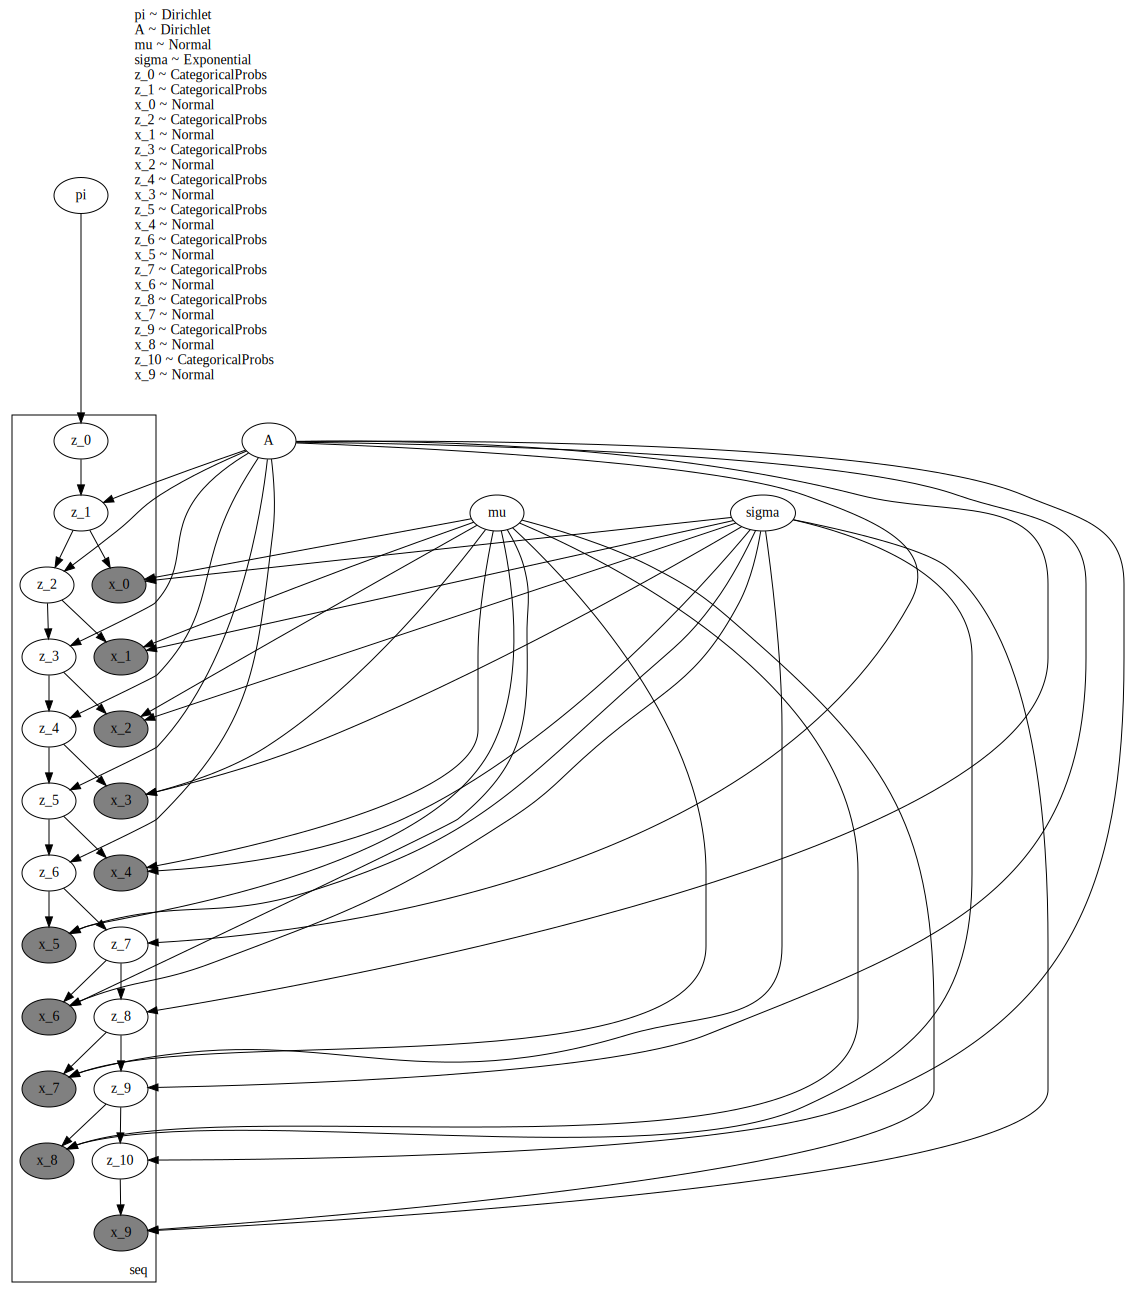

In [39]:
numpyro.render_model(gaussian_hmm_model, model_args=(X0,L0,K), render_distributions=True)

Initializes and trains the Gaussian HMM using stochastic variational inference (SVI) by repeatedly sampling batches of sequences and updating the model parameters

In [40]:
rng = random.PRNGKey(0)
rng, sk = random.split(rng)
# Randomly samples indices for the first batch
idx0 = np.array(random.choice(sk, len(train_seqs_list), (batch_size,), replace=False))

# Create a padded batch of sequences
X0, L0 = make_batch_fixed_T(train_seqs_list, train_lengths, idx0, Tmax_fixed)

svi_state = svi.init(rng, X0, L0, K=K)

for step in range(num_steps):
    # Split RNG for new random operations
    rng, sk = random.split(rng)
    idx = np.array(random.choice(sk, len(train_seqs_list), (batch_size,), replace=False))
    Xb, Lb = make_batch_fixed_T(train_seqs_list, train_lengths, idx, Tmax_fixed)
    svi_state, loss = svi.update(svi_state, Xb, Lb, K=K)

    if step % 100 == 0:
        print(f"step={step:4d} loss={float(loss):.2f}")

params_svi = svi.get_params(svi_state)
print("done")
# Confirms training finished and show some parameter names
print(list(params_svi.keys())[:10])

step=   0 loss=310.68
step= 100 loss=216.69
step= 200 loss=251.23
step= 300 loss=189.86
step= 400 loss=191.57
step= 500 loss=558.75
step= 600 loss=178.87
step= 700 loss=218.87
step= 800 loss=165.01
step= 900 loss=176.43
done
['A_auto_loc', 'A_auto_scale', 'mu_auto_loc', 'mu_auto_scale', 'pi_auto_loc', 'pi_auto_scale', 'sigma_auto_loc', 'sigma_auto_scale']


Draws samples from the learned variational posterior to estimate distributions of the continuous HMM parameters (pi, A, mu, sigma)

In [41]:
params_svi = svi.get_params(svi_state)

# sample from variational posterior (guide) for continuous params
rng = random.PRNGKey(1)
n_post = 200  # 200–500 is fine

predictive = Predictive(
    gaussian_hmm_model,           # model
    guide=guide,                  # variational posterior
    params=params_svi,            # learned parameters of the guide
    num_samples=n_post,           # number of posterior samples to draw
    return_sites=["pi","A","mu","sigma"]  # only continuous params
)

# use a small dummy batch for shapes (same D)
# easiest: reuse your last minibatch Xb,Lb (or create one batch)
posterior = predictive(rng, X0, L0, K=K)

for k,v in posterior.items():
    print(k, v.shape)

A (200, 3, 3)
mu (200, 3, 5)
pi (200, 3)
sigma (200, 3, 5)


Computes point estimates of the HMM parameters by taking the mean of the sampled posterior distributions

In [42]:
pi_hat = posterior["pi"].mean(axis=0)          # (K,)
A_hat  = posterior["A"].mean(axis=0)           # (K,K)
mu_hat = posterior["mu"].mean(axis=0)          # (K,D)
sg_hat = posterior["sigma"].mean(axis=0)       # (K,D)

### `log_normal_diag` Compute Gaussian emission log-probabilities for each hidden state

This function computes the **log probability of each observation under each hidden state's Gaussian emission distribution**.

In the Hidden Markov Model, every hidden state \(z = k\) emits observations according to a **multivariate Gaussian distribution with diagonal covariance**.

For a sequence of observations:

- **T** = number of time steps in the sequence  
- **D** = number of observed features (CPU / RAM statistics)  
- **K** = number of hidden states  

The function returns a **(T × K) matrix**, where each entry represents:

$$
\log p(x_t \mid z_t = k)
$$

To compute this efficiently, the function **broadcasts the observation sequence against all state parameters simultaneously**, allowing all states and time steps to be evaluated without loops.

Computes the log-likelihood of observations under each Gaussian state in the HMM using a diagonal covariance assumption

In [43]:
def log_normal_diag(x, mu, sigma):
    # x: observation sequence (T,D)
    # mu/sigma: Gaussian parameters for each time and state (K,D)
    # returns log p(x_t | z=k) as (T,K)

    # Expand observations so they broadcast across
    x = x[:, None, :]               # (T,1,D)
    mu = mu[None, :, :]             # (1,K,D)
    sg = sigma[None, :, :]          # (1,K,D)

    # Compute Gaussian log-density and sum across feature dimension D
    return (-0.5 * (((x - mu) / sg) ** 2 + 2*np.log(sg) + np.log(2*np.pi))).sum(-1)

### `forward_probs` Compute filtered hidden-state probabilities using the Forward algorithm

This function implements the **Forward algorithm** for a Hidden Markov Model (HMM).

Unlike the Viterbi algorithm, which finds the **single most likely state path**, the
Forward algorithm computes the **probability distribution over hidden states at each
time step**, given all observations up to that time.

For each time step \(t\), it computes:

$$
P(z_t = k \mid x_1, \dots, x_t)
$$

where:

- \(x_t\) is the observation vector at time step \(t\)
- \(z_t\) is the hidden state
- \(k\) indexes the possible states

The algorithm works recursively:

1. **Initialization**  
   Combine the initial state probabilities with the emission probability of the first observation.

2. **Forward recursion**  
   For each time step, accumulate probability mass from all previous states through
   the transition matrix.

3. **Normalization**  
   At each step we normalize the log probabilities to avoid numerical underflow.

The result is a matrix **gamma_filt (T × K)** where each row represents the
probability distribution over hidden states at time \(t\).

Computes filtered hidden state probabilities for each time step using the HMM forward algorithm, then adds those probabilities as new columns to the dataframe

In [44]:
def forward_probs(X, pi, A, mu, sigma):
    # X: observation sequence (T, D)
    # pi: initial state probabilities (K,)
    # A: transition matrix (K, K)
    # mu, sigma: Gaussian parameters for each state (K, D)
    # Returns gamma_filt: filtered state probabilities (T, K)

    T = X.shape[0]
    K = pi.shape[0]

    # Compute log emission probabilities log p(x_t | z_t=k)
    logB = log_normal_diag(X, mu, sigma)   # (T, K)

    # Convert initial and transition probabilities to log-space
    logpi = np.log(pi + 1e-12)             # (K,)
    logA = np.log(A + 1e-12)               # (K, K)

    # Allocate forward probability matrix
    log_alpha = np.zeros((T, K), dtype=np.float64)

    # t = 0
    log_alpha[0] = logpi + logB[0]
    log_alpha[0] -= logsumexp(log_alpha[0])   # normalize

    # t = 1, ..., T-1
    for t in range(1, T):
        # for each current state k:
        # log_alpha[t, k] = logB[t, k] + logsumexp_j(log_alpha[t-1, j] + logA[j, k])
        trans_scores = log_alpha[t - 1][:, None] + logA   # (K, K)
        log_alpha[t] = logB[t] + logsumexp(trans_scores, axis=0)
        log_alpha[t] -= logsumexp(log_alpha[t])           # normalize

    gamma_filt = np.exp(log_alpha)   # (T, K), rows sum to ~1
    return gamma_filt

Adds the computed HMM state probabilities for each event in the dataframe based on its job sequence

### `add_forward_state_probs` Add filtered HMM state probabilities back to the dataframe

This function applies the **Forward algorithm** to every job sequence in the dataset and
writes the resulting hidden-state probabilities back into the dataframe.

Each sequence is defined by the pair:

- `collection_id`
- `instance_index`

For every sequence, the rows are first **sorted by time** so that the Forward algorithm
receives the observations in the correct temporal order.

The Forward algorithm returns a matrix:

$$
\gamma_{t,k} = P(z_t = k \mid x_1, \dots, x_t)
$$

where:
- \(t\) = time step
- \(k\) = hidden state

These probabilities represent the **filtered belief** of being in each hidden state
after observing data up to time \(t\).

The function then writes these probabilities back into the dataframe as new columns:

- `hmm_state_0_prob`
- `hmm_state_1_prob`
- ...
- `hmm_state_{K-1}_prob`

Each row therefore contains the **probability distribution over hidden states**
for that observation.

In [45]:
def add_forward_state_probs(df, feature_set, pi, A, mu, sigma, time_col="start_time"):
    # df: dataframe containing job observations
    # feature_set: columns used as HMM features
    # pi, A, mu, sigma: learned HMM parameters
    # Returns dataframe with state probability columns added
    df_out = df.copy()

    K = len(pi)
    # Create column names for each hidden state probability
    prob_cols = [f"hmm_state_{k}_prob" for k in range(K)]

    # initialize probability columns
    for col in prob_cols:
        df_out[col] = np.nan

    # preserve original row identity so we can write back in correct order
    df_out["_orig_idx"] = np.arange(len(df_out))

    for (cid, iid), g in df_out.groupby(["collection_id", "instance_index"], sort=False):
        # Process each job instance in time order
        g_sorted = g.sort_values(time_col)

        # Extract feature sequence
        X = g_sorted[feature_set].to_numpy(dtype=np.float32)

        if X.shape[0] == 0:
            continue

        # Compute filtered state probabilities
        probs = forward_probs(X, pi, A, mu, sigma)   # (T, K)

        # assign back row-by-row in sorted time order
        df_out.loc[g_sorted.index, prob_cols] = probs

    df_out = df_out.drop(columns="_orig_idx")
    return df_out

Computes the most likely sequence of hidden states for an observation sequence using the Viterbi algorithm

### `viterbi_path` Compute the most likely hidden state sequence using the Viterbi algorithm

This function implements the **Viterbi algorithm**, which finds the single most
likely sequence of hidden states given an observation sequence.

While the Forward algorithm computes **state probabilities at each time step**,  
the Viterbi algorithm instead computes the **most likely state path**.

For a sequence of observations \(x_1, ..., x_T\), the algorithm finds:

$$
\hat{z}_{1:T} = \arg\max_{z_{1:T}} P(z_{1:T}, x_{1:T})
$$

The algorithm proceeds in three steps:

1. **Initialization**  
   Combine initial state probabilities with the emission probability
   of the first observation.

2. **Recursion**  
   For each time step, compute the best previous state transition
   and store both the score and the backpointer.

3. **Backtracking**  
   Starting from the final state with the highest probability,
   follow the stored backpointers to reconstruct the optimal state path.

The output is a vector of length \(T\) where each entry contains the
most likely hidden state for that observation.

In [46]:
def viterbi_path(X, pi, A, mu, sigma):
    # X: observation sequence (T, D)
    # pi: initial state probabilities (K,)
    # A: transition matrix (K, K)
    # mu, sigma: Gaussian emission parameters (K, D)
    # Returns path: most likely hidden state sequence (T,)

    T = X.shape[0]
    K = pi.shape[0]

    # Compute emission log probabilities
    logB = log_normal_diag(X, mu, sigma)   # (T, K)
    logpi = np.log(pi + 1e-12)
    logA = np.log(A + 1e-12)

    delta = np.zeros((T, K), dtype=np.float64)
    psi = np.zeros((T, K), dtype=np.int32)

    # initialization
    delta[0] = logpi + logB[0]

    # recursion
    for t in range(1, T):
        for k in range(K):
            scores = delta[t - 1] + logA[:, k]
            psi[t, k] = np.argmax(scores)
            delta[t, k] = np.max(scores) + logB[t, k]

    # backtrack
    path = np.zeros(T, dtype=np.int32)
    path[-1] = np.argmax(delta[-1])

    for t in range(T - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]

    return path

### Add the most likely Viterbi state back to each dataframe row

This function applies the **Viterbi algorithm** to every job sequence in the dataframe
and writes the resulting most likely hidden state back as a new column.

Each sequence is defined by the pair:

- `collection_id`
- `instance_index`

For every sequence, the rows are first **sorted by time** so that the HMM is decoded
in the correct temporal order.

The Viterbi algorithm returns a vector of length \(T\), where each entry is the
most likely hidden state for that time step:

$$
\hat{z}_t = \arg\max_k P(z_t = k \mid x_{1:T})
$$

These decoded states are then assigned back to the corresponding rows in the dataframe
as a new column:

- `viterbi_state`

This gives each observation a single discrete hidden-state label, which can then be
used for interpretation, visualization, or downstream failure-risk analysis.

In [47]:
def add_viterbi_state_column(df, feature_set, pi, A, mu, sigma, time_col="start_time"):
    # df: dataframe containing job observations
    # feature_set: columns used as HMM features
    # pi, A, mu, sigma: learned HMM parameters
    # Returns dataframe with a new column "viterbi_state"

    df_out = df.copy()
    df_out["viterbi_state"] = np.nan

    for (cid, iid), g in df_out.groupby(["collection_id", "instance_index"], sort=False):
        g_sorted = g.sort_values(time_col)

        X = g_sorted[feature_set].to_numpy(dtype=np.float32)

        if len(X) == 0:
            continue

        path = viterbi_path(X, pi, A, mu, sigma)

        df_out.loc[g_sorted.index, "viterbi_state"] = path

    df_out["viterbi_state"] = df_out["viterbi_state"].astype("Int64")
    return df_out

### Decode hidden state sequences for all training jobs using the Viterbi algorithm

After training the HMM using JAX, the learned parameters are stored as JAX arrays.
Since the decoding functions in this notebook operate using NumPy, the parameters
must first be converted to NumPy arrays.

The learned parameters are:

- `pi_hat` – initial state probabilities  
- `A_hat` – transition matrix  
- `mu_hat` – emission means  
- `sg_hat` – emission standard deviations  

Next, the Viterbi algorithm is applied to every observation sequence in the training
set (`train_seqs_list`). Each sequence corresponds to a job instance and contains
a matrix of observations with shape:

\[
(T, D)
\]

where:

- \(T\) = number of time steps in the sequence  
- \(D\) = number of features  

The Viterbi algorithm returns the **most likely hidden state sequence** for each job.

These decoded state paths are stored in `train_z_paths`, which becomes a list of
arrays containing the inferred state sequence for every training job.

In [48]:
# convert jax arrays to numpy for decode
pi_np = np.array(pi_hat)
A_np  = np.array(A_hat)
mu_np = np.array(mu_hat)
sg_np = np.array(sg_hat)

# decode train jobs (use full ragged seq or fixed window)
train_z_paths = []
for seq in train_seqs_list:
    X = np.array(seq)  # (T,D)
    z = viterbi_path(X, pi_np, A_np, mu_np, sg_np)
    train_z_paths.append(z)

print(len(train_z_paths), train_z_paths[0].shape)

724 (500,)


In [49]:
train_df = add_forward_state_probs(
    df=train_df,
    feature_set=feature_set,
    pi=pi_np,
    A=A_np,
    mu=mu_np,
    sigma=sg_np,
    time_col="start_time"
)

In [50]:
train_df[[
    "collection_id",
    "instance_index",
    "start_time",
    "hmm_state_0_prob",
    "hmm_state_1_prob",
    "hmm_state_2_prob"
]].head()

,collection_id,instance_index,start_time,hmm_state_0_prob,hmm_state_1_prob,hmm_state_2_prob
0,9941075899,8,1704900000000,1.000000,2.309993e-27,1.162457e-11
1,9941075899,8,2061900000000,1.000000,2.121209e-26,4.650603e-12
2,84700535897,0,166614000000,0.267206,2.162186e-06,7.327914e-01
3,84700535897,0,346323000000,0.643197,3.568034e-01,5.815083e-29
4,84700535897,0,943217000000,0.610655,3.893446e-01,6.127563e-29


In [51]:
# import numpy as np
# from jax.tree_util import tree_map

# params_svi = svi.get_params(svi_state)

# # convert JAX arrays -> numpy arrays (so np.save works cleanly)
# params_np = tree_map(lambda x: np.array(x), params_svi)

# np.savez("svi_params.npz", **params_np)
# print("saved svi_params.npz with keys:", list(params_np.keys()))


In [52]:
train_df.columns

Index(['start_time', 'collection_id', 'instance_index', 'average_usage_cpus',
       'average_usage_memory', 'maximum_usage_cpus', 'maximum_usage_memory',
       'cycles_per_instruction', 'random_sample_usage_cpus',
       'random_sample_usage_memory', 'assigned_memory', 'page_cache_memory',
       'memory_accesses_per_instruction', 'cpu_usage_distribution',
       'tail_cpu_usage_distribution', 'last_event', 'cpu_p0', 'cpu_p10',
       'cpu_p20', 'cpu_p30', 'cpu_p40', 'cpu_p50', 'cpu_p60', 'cpu_p70',
       'cpu_p80', 'cpu_p90', 'cpu_p100', 'cpu_burstiness', 'tail_cpu_mean',
       'tail_cpu_max', 'tail_cpu_p90', 'tail_cpu_nonzero_frac', 'kill_row',
       'average_usage_cpus_logged', 'average_usage_cpus_logged_normed',
       'average_usage_memory_logged', 'average_usage_memory_logged_normed',
       'maximum_usage_cpus_logged', 'maximum_usage_cpus_logged_normed',
       'maximum_usage_memory_logged', 'maximum_usage_memory_logged_normed',
       'assigned_memory_logged', 'assigned_me

In [53]:
train_df["state_prob_sum"] = (
    train_df["hmm_state_0_prob"] +
    train_df["hmm_state_1_prob"] +
    train_df["hmm_state_2_prob"]
)

train_df["state_prob_sum"].describe()

,state_prob_sum
count,2.545580e+06
mean,1.000000e+00
std,2.508198e-16
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


In [54]:
train_df = add_viterbi_state_column(
    df=train_df,
    feature_set=feature_set,
    pi=pi_np,
    A=A_np,
    mu=mu_np,
    sigma=sg_np,
    time_col="start_time"
)

In [55]:
train_df["dominant_forward_state"] = train_df[
    ["hmm_state_0_prob", "hmm_state_1_prob", "hmm_state_2_prob"]
].to_numpy().argmax(axis=1)

In [56]:
train_df[[
    "collection_id",
    "instance_index",
    "start_time",
    "dominant_forward_state",
    "viterbi_state",
    "hmm_state_0_prob",
    "hmm_state_1_prob",
    "hmm_state_2_prob"
]].head()

,collection_id,instance_index,start_time,dominant_forward_state,viterbi_state,hmm_state_0_prob,hmm_state_1_prob,hmm_state_2_prob
0,9941075899,8,1704900000000,0,0,1.000000,2.309993e-27,1.162457e-11
1,9941075899,8,2061900000000,0,0,1.000000,2.121209e-26,4.650603e-12
2,84700535897,0,166614000000,2,0,0.267206,2.162186e-06,7.327914e-01
3,84700535897,0,346323000000,0,0,0.643197,3.568034e-01,5.815083e-29
4,84700535897,0,943217000000,0,0,0.610655,3.893446e-01,6.127563e-29


In [57]:
# VALIDATION

In [58]:
test_df = add_forward_state_probs(
    df=test_df,
    feature_set=feature_set,
    pi=pi_np,
    A=A_np,
    mu=mu_np,
    sigma=sg_np,
    time_col="start_time"
)

test_df["dominant_forward_state"] = test_df[
    ["hmm_state_0_prob", "hmm_state_1_prob", "hmm_state_2_prob"]
].to_numpy().argmax(axis=1)

In [59]:
test_df = add_viterbi_state_column(
    df=test_df,
    feature_set=feature_set,
    pi=pi_np,
    A=A_np,
    mu=mu_np,
    sigma=sg_np,
    time_col="start_time"
)

In [60]:
print(train_df["kill_row"].value_counts())

kill_row
0    2542539
1       3041
Name: count, dtype: int64


In [61]:
print(test_df["kill_row"].value_counts())

kill_row
0    705438
1       995
Name: count, dtype: int64


In [62]:
cid = 360439471976
iid = 2

df_check = train_df[
    (train_df["collection_id"] == cid) &
    (train_df["instance_index"] == iid)
].sort_values("start_time")

print(df_check[["collection_id", "instance_index", "start_time", "kill_row"]].tail(30))

Empty DataFrame
Columns: [collection_id, instance_index, start_time, kill_row]
Index: []


In [63]:
kill_check = instance_events_df[
    (instance_events_df["collection_id"] == cid) &
    (instance_events_df["instance_index"] == iid) &
    (instance_events_df["type"].isin([5, 7]))
].sort_values("time")

print(kill_check[["collection_id", "instance_index", "time", "type"]])

        collection_id  instance_index           time  type
120236   360439471976               2   463523319524     5
78370    360439471976               2   463829049980     5
72670    360439471976               2   467835949000     5
33074    360439471976               2   471361793303     5
78374    360439471976               2   484762444517     5
...               ...             ...            ...   ...
28615    360439471976               2  2518353010544     5
28629    360439471976               2  2536821651921     5
55367    360439471976               2  2538929396828     5
53704    360439471976               2  2541116911854     5
28582    360439471976               2  2541807061933     5

[132 rows x 4 columns]


In [64]:
# only rows marked as kill rows
kill_df = train_df[train_df["kill_row"] == 1].copy()

# dominant forward state breakdown
dominant_breakdown = (
    kill_df.groupby("dominant_forward_state")
    .size()
    .div(len(kill_df))
    .mul(100)
    .reset_index(name="percent")
)

print("TRAIN Dominant forward state breakdown among kill_row == 1:")
print(dominant_breakdown)

# viterbi state breakdown
viterbi_breakdown = (
    kill_df.groupby("viterbi_state")
    .size()
    .div(len(kill_df))
    .mul(100)
    .reset_index(name="percent")
)

print("\nTRAIN Viterbi state breakdown among kill_row == 1:")
print(viterbi_breakdown)

TRAIN Dominant forward state breakdown among kill_row == 1:
   dominant_forward_state    percent
0                       0  14.304505
1                       1  75.764551
2                       2   9.930944

TRAIN Viterbi state breakdown among kill_row == 1:
   viterbi_state    percent
0              0  12.134166
1              1  78.197961
2              2   9.667872


In [65]:
# only rows marked as kill rows
kill_df = test_df[test_df["kill_row"] == 1].copy()

# dominant forward state breakdown
dominant_breakdown = (
    kill_df.groupby("dominant_forward_state")
    .size()
    .div(len(kill_df))
    .mul(100)
    .reset_index(name="percent")
)

print("TEST Dominant forward state breakdown among kill_row == 1:")
print(dominant_breakdown)


# viterbi state breakdown
viterbi_breakdown = (
    kill_df.groupby("viterbi_state")
    .size()
    .div(len(kill_df))
    .mul(100)
    .reset_index(name="percent")
)

print("\nTEST Viterbi state breakdown among kill_row == 1:")
print(viterbi_breakdown)

TEST Dominant forward state breakdown among kill_row == 1:
   dominant_forward_state    percent
0                       0   8.944724
1                       1  85.125628
2                       2   5.929648

TEST Viterbi state breakdown among kill_row == 1:
   viterbi_state    percent
0              0   5.427136
1              1  88.743719
2              2   5.829146


In [66]:
state_kill_rate = (
    train_df.groupby("dominant_forward_state")["kill_row"]
    .mean()
    .mul(100)
    .reset_index(name="kill_rate_percent")
)

print(state_kill_rate)

   dominant_forward_state  kill_rate_percent
0                       0           0.195667
1                       1           0.254831
2                       2           0.021281


In [67]:
state_kill_rate = (
    test_df.groupby("dominant_forward_state")["kill_row"]
    .mean()
    .mul(100)
    .reset_index(name="kill_rate_percent")
)

print(state_kill_rate)

   dominant_forward_state  kill_rate_percent
0                       0           0.196916
1                       1           0.277903
2                       2           0.016552


<Axes: title={'center': 'Kill probability by HMM state'}, xlabel='Hidden state', ylabel='P(kill | state)'>

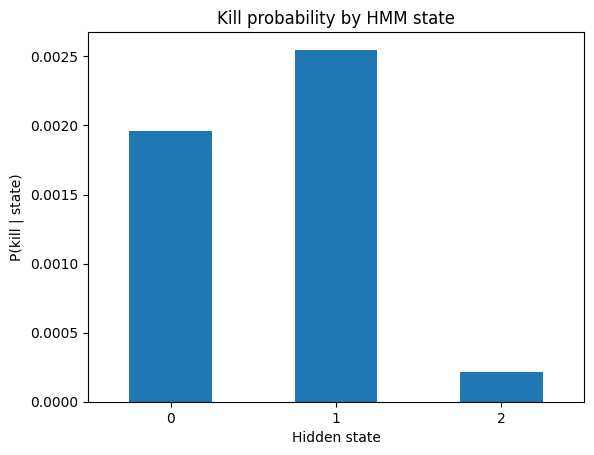

In [68]:
state_kill_rate = train_df.groupby("dominant_forward_state")["kill_row"].mean()

state_kill_rate.plot(
    kind="bar",
    title="Kill probability by HMM state",
    ylabel="P(kill | state)",
    xlabel="Hidden state",
    rot=0
)

In [69]:
baseline = train_df["kill_row"].mean()

state_kill_rate = train_df.groupby("dominant_forward_state")["kill_row"].mean()

risk_ratio = state_kill_rate / baseline

print(risk_ratio)

dominant_forward_state
0    1.637898
1    2.133155
2    0.178137
Name: kill_row, dtype: float64


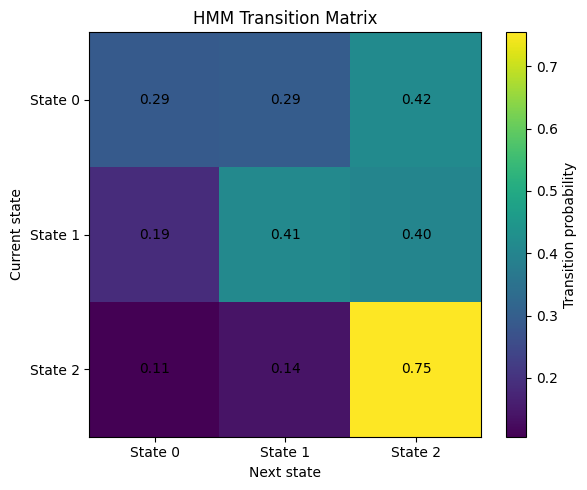

In [70]:
A_df = pd.DataFrame(
    A_np,
    index=[f"State {i}" for i in range(A_np.shape[0])],
    columns=[f"State {i}" for i in range(A_np.shape[1])]
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(A_df.values, aspect="auto")

ax.set_xticks(range(A_df.shape[1]))
ax.set_yticks(range(A_df.shape[0]))
ax.set_xticklabels(A_df.columns)
ax.set_yticklabels(A_df.index)

ax.set_xlabel("Next state")
ax.set_ylabel("Current state")
ax.set_title("HMM Transition Matrix")

for i in range(A_df.shape[0]):
    for j in range(A_df.shape[1]):
        ax.text(j, i, f"{A_df.iloc[i, j]:.2f}", ha="center", va="center")

plt.colorbar(im, ax=ax, label="Transition probability")
plt.tight_layout()
plt.show()

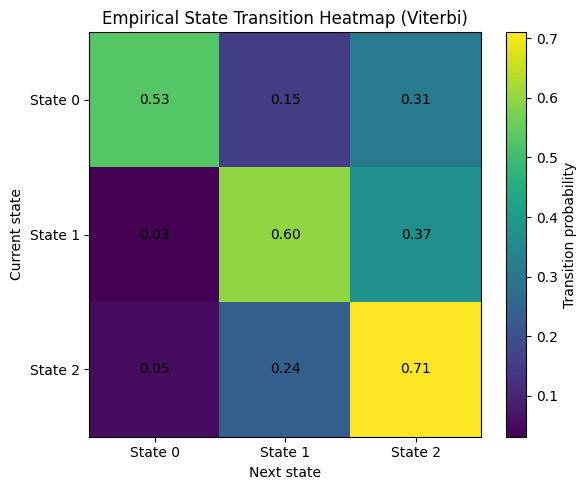

In [71]:
# sort rows properly
df_sorted = train_df.sort_values(["collection_id", "instance_index", "start_time"]).copy()

# next state within each sequence
df_sorted["next_state"] = df_sorted.groupby(
    ["collection_id", "instance_index"]
)["viterbi_state"].shift(-1)

# keep only valid within-sequence transitions
transitions = df_sorted.dropna(subset=["viterbi_state", "next_state"]).copy()
transitions["next_state"] = transitions["next_state"].astype(int)
transitions["viterbi_state"] = transitions["viterbi_state"].astype(int)

# count transitions
trans_counts = pd.crosstab(
    transitions["viterbi_state"],
    transitions["next_state"]
).reindex(index=[0,1,2], columns=[0,1,2], fill_value=0)

# row-normalize to get probabilities
trans_probs = trans_counts.div(trans_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(trans_probs.values, aspect="auto")

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f"State {i}" for i in range(3)])
ax.set_yticklabels([f"State {i}" for i in range(3)])

ax.set_xlabel("Next state")
ax.set_ylabel("Current state")
ax.set_title("Empirical State Transition Heatmap (Viterbi)")

for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{trans_probs.iloc[i, j]:.2f}", ha="center", va="center")

plt.colorbar(im, ax=ax, label="Transition probability")
plt.tight_layout()
plt.show()

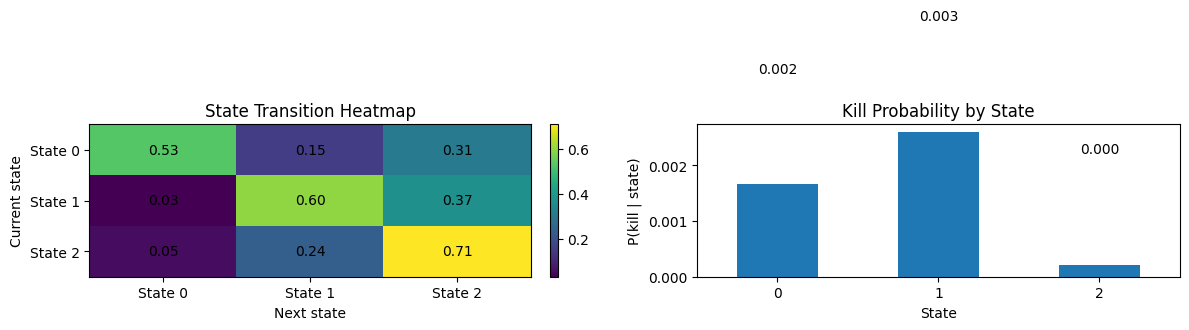

In [72]:
# --- empirical transition matrix ---
df_sorted = train_df.sort_values(["collection_id", "instance_index", "start_time"]).copy()
df_sorted["next_state"] = df_sorted.groupby(
    ["collection_id", "instance_index"]
)["viterbi_state"].shift(-1)

transitions = df_sorted.dropna(subset=["viterbi_state", "next_state"]).copy()
transitions["viterbi_state"] = transitions["viterbi_state"].astype(int)
transitions["next_state"] = transitions["next_state"].astype(int)

trans_counts = pd.crosstab(
    transitions["viterbi_state"],
    transitions["next_state"]
).reindex(index=[0,1,2], columns=[0,1,2], fill_value=0)

trans_probs = trans_counts.div(trans_counts.sum(axis=1), axis=0)

# --- kill probability ---
state_kill_rate = (
    train_df.groupby("viterbi_state")["kill_row"]
    .mean()
    .reindex([0,1,2], fill_value=0)
)

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: heatmap
im = axes[0].imshow(trans_probs.values, aspect="auto")
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
axes[0].set_xticklabels([f"State {i}" for i in range(3)])
axes[0].set_yticklabels([f"State {i}" for i in range(3)])
axes[0].set_xlabel("Next state")
axes[0].set_ylabel("Current state")
axes[0].set_title("State Transition Heatmap")

for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{trans_probs.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# right: kill probability
state_kill_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Kill Probability by State")
axes[1].set_xlabel("State")
axes[1].set_ylabel("P(kill | state)")
axes[1].set_xticklabels([0,1,2], rotation=0)

for i, v in enumerate(state_kill_rate.values):
    axes[1].text(i, v + 0.002, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

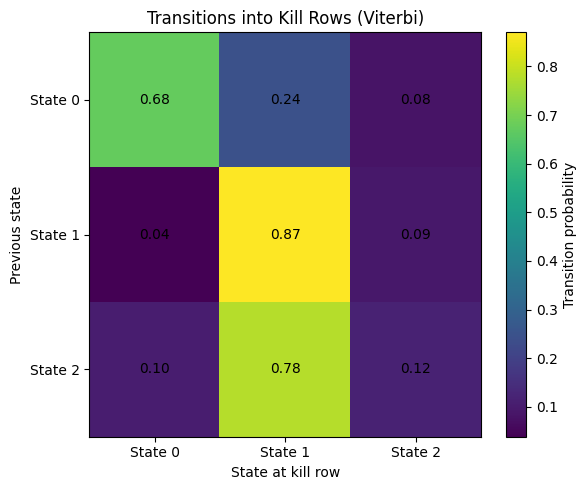

In [73]:
# sort within each sequence
df_sorted = train_df.sort_values(["collection_id", "instance_index", "start_time"]).copy()

# previous state within each sequence
df_sorted["prev_state"] = df_sorted.groupby(
    ["collection_id", "instance_index"]
)["viterbi_state"].shift(1)

# keep only rows that are kill rows and have a previous state
prekill = df_sorted[
    (df_sorted["kill_row"] == 1) &
    (df_sorted["prev_state"].notna()) &
    (df_sorted["viterbi_state"].notna())
].copy()

prekill["prev_state"] = prekill["prev_state"].astype(int)
prekill["viterbi_state"] = prekill["viterbi_state"].astype(int)

# transition counts: prev_state -> current kill-row state
prekill_counts = pd.crosstab(
    prekill["prev_state"],
    prekill["viterbi_state"]
).reindex(index=[0,1,2], columns=[0,1,2], fill_value=0)

# row-normalize
prekill_probs = prekill_counts.div(prekill_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

# plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(prekill_probs.values, aspect="auto")

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f"State {i}" for i in range(3)])
ax.set_yticklabels([f"State {i}" for i in range(3)])

ax.set_xlabel("State at kill row")
ax.set_ylabel("Previous state")
ax.set_title("Transitions into Kill Rows (Viterbi)")

for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{prekill_probs.iloc[i, j]:.2f}", ha="center", va="center")

plt.colorbar(im, ax=ax, label="Transition probability")
plt.tight_layout()
plt.show()

In [74]:
df_sorted = train_df.sort_values(["collection_id", "instance_index", "start_time"]).copy()

df_sorted["prev_state"] = df_sorted.groupby(
    ["collection_id", "instance_index"]
)["viterbi_state"].shift(1)

prekill_prev_state = df_sorted[
    (df_sorted["kill_row"] == 1) &
    (df_sorted["prev_state"].notna())
].copy()

prekill_prev_state["prev_state"] = prekill_prev_state["prev_state"].astype(int)

prev_state_summary = (
    prekill_prev_state.groupby("prev_state")
    .size()
    .reindex([0,1,2], fill_value=0)
    .div(len(prekill_prev_state))
    .mul(100)
    .reset_index(name="percent")
)

print("State distribution immediately before a kill:")
print(prev_state_summary)

State distribution immediately before a kill:
   prev_state    percent
0           0  10.526316
1           1  65.657895
2           2  23.815789


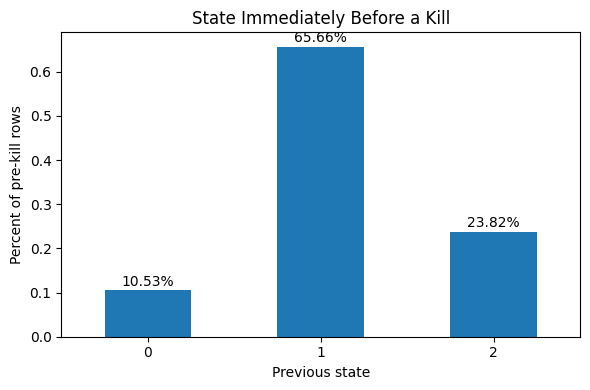

In [75]:
prev_state_rate = (
    prekill_prev_state.groupby("prev_state")
    .size()
    .reindex([0,1,2], fill_value=0)
    .div(len(prekill_prev_state))
)

fig, ax = plt.subplots(figsize=(6, 4))
prev_state_rate.plot(kind="bar", ax=ax)

ax.set_title("State Immediately Before a Kill")
ax.set_xlabel("Previous state")
ax.set_ylabel("Percent of pre-kill rows")
ax.set_xticklabels([0,1,2], rotation=0)

for i, v in enumerate(prev_state_rate.values):
    ax.text(i, v + 0.01, f"{v:.2%}", ha="center")

plt.tight_layout()
plt.show()

In [76]:
overall_prev = (
    df_sorted["viterbi_state"]
    .value_counts(normalize=True)
    .reindex([0,1,2], fill_value=0)
)

prekill_prev = (
    prekill_prev_state["prev_state"]
    .value_counts(normalize=True)
    .reindex([0,1,2], fill_value=0)
)

compare_df = pd.DataFrame({
    "overall_state_dist": overall_prev.values,
    "pre_kill_prev_state_dist": prekill_prev.values
}, index=[0,1,2])

print(compare_df)

   overall_state_dist  pre_kill_prev_state_dist
0            0.087364                  0.105263
1             0.35888                  0.656579
2            0.553756                  0.238158


In [77]:
df_sorted = train_df.sort_values(["collection_id", "instance_index", "start_time"]).copy()

df_sorted["prev_dom_state"] = df_sorted.groupby(
    ["collection_id", "instance_index"]
)["dominant_forward_state"].shift(1)

prekill_dom = df_sorted[
    (df_sorted["kill_row"] == 1) &
    (df_sorted["prev_dom_state"].notna())
].copy()

prekill_dom["prev_dom_state"] = prekill_dom["prev_dom_state"].astype(int)

dom_prev_summary = (
    prekill_dom.groupby("prev_dom_state")
    .size()
    .reindex([0,1,2], fill_value=0)
    .div(len(prekill_dom))
    .mul(100)
    .reset_index(name="percent")
)

print("Dominant forward state immediately before a kill:")
print(dom_prev_summary)

Dominant forward state immediately before a kill:
   prev_dom_state    percent
0               0  10.296053
1               1  65.328947
2               2  24.375000


In [78]:
feature_set

['average_usage_cpus_logged_normed',
 'cpu_p90_logged_normed',
 'average_usage_memory_logged_normed',
 'assigned_memory_logged_normed',
 'cpu_burstiness_logged_normed']

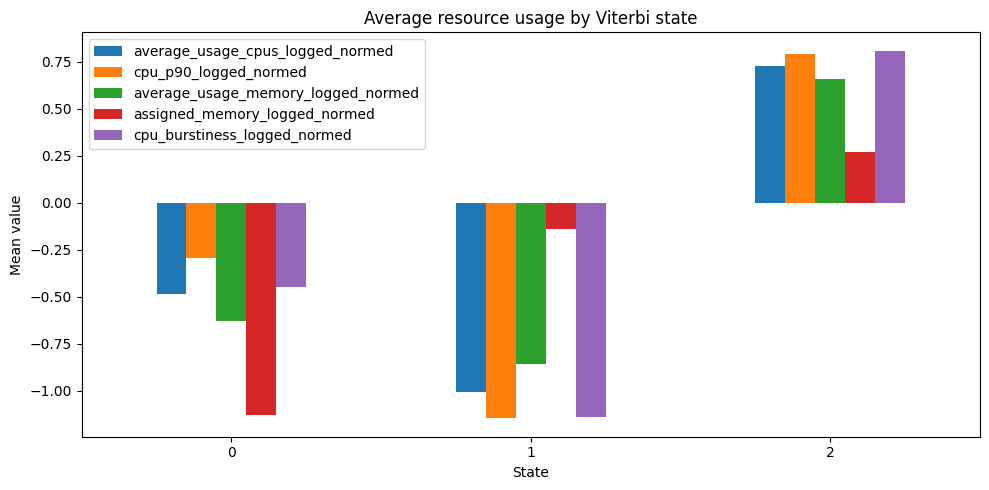

In [79]:
summary = train_df.groupby("viterbi_state")[['average_usage_cpus_logged_normed',
 'cpu_p90_logged_normed',
 'average_usage_memory_logged_normed',
 'assigned_memory_logged_normed',
 'cpu_burstiness_logged_normed']].mean()

summary.plot(kind="bar", figsize=(10,5))
plt.title("Average resource usage by Viterbi state")
plt.ylabel("Mean value")
plt.xlabel("State")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

(array([1.888e+03, 5.600e+01, 1.600e+01, 9.000e+00, 0.000e+00, 2.000e+00,
        3.000e+00, 6.000e+00, 7.000e+00, 1.000e+00]),
 array([1.00000e+00, 5.78670e+03, 1.15724e+04, 1.73581e+04, 2.31438e+04,
        2.89295e+04, 3.47152e+04, 4.05009e+04, 4.62866e+04, 5.20723e+04,
        5.78580e+04]),
 <BarContainer object of 10 artists>)

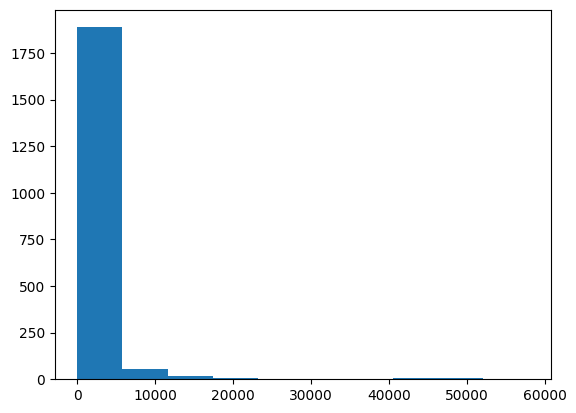

In [80]:
state_durations = (
    train_df.groupby(["collection_id","instance_index","viterbi_state"])
    .size()
)
plt.hist(state_durations)

In [81]:
train_df.groupby("viterbi_state")[feature_set].mean()

,average_usage_cpus_logged_normed,cpu_p90_logged_normed,average_usage_memory_logged_normed,assigned_memory_logged_normed,cpu_burstiness_logged_normed
viterbi_state,,,,,
0,-0.485543,-0.295072,-0.629850,-1.128605,-0.450739
1,-1.004704,-1.146688,-0.859870,-0.139956,-1.138060
2,0.727736,0.789703,0.656638,0.268759,0.808671


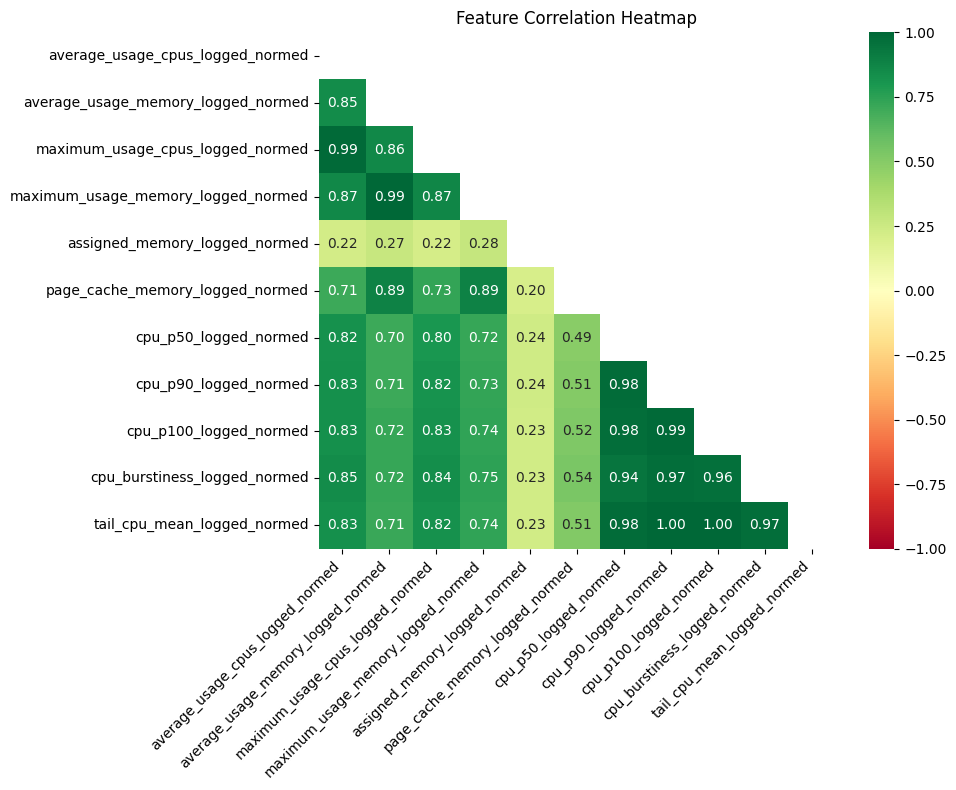

In [82]:
# correlation matrix
corr = train_df[candidate_feature_set].corr()

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="RdYlGn",   # red → yellow → green
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

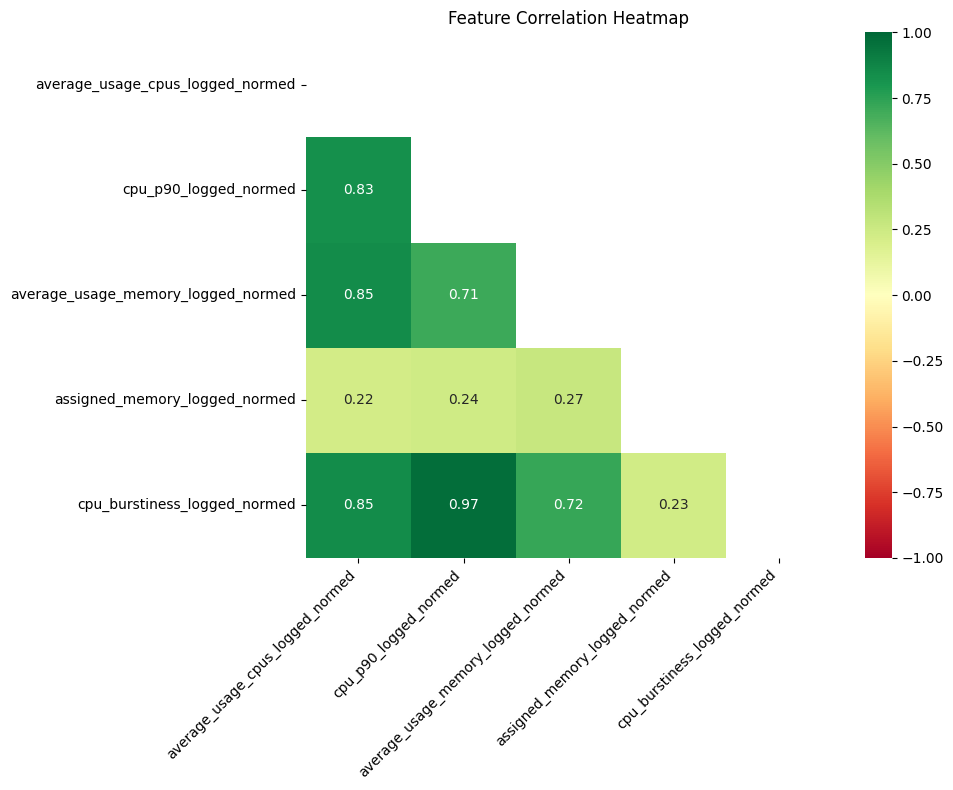

In [83]:
# correlation matrix
corr = train_df[feature_set].corr()

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="RdYlGn",   # red → yellow → green
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

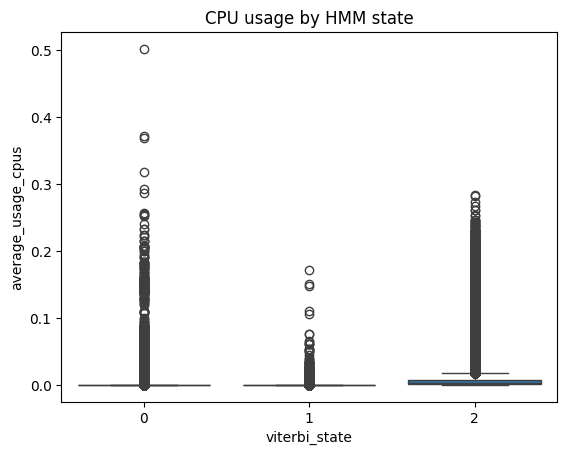

In [84]:
sns.boxplot(data=train_df, x="viterbi_state", y="average_usage_cpus")
plt.title("CPU usage by HMM state")
plt.show()

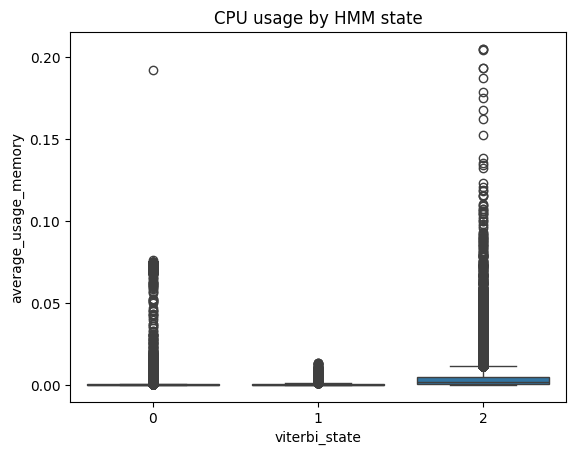

In [85]:
sns.boxplot(data=train_df, x="viterbi_state", y="average_usage_memory")
plt.title("CPU usage by HMM state")
plt.show()

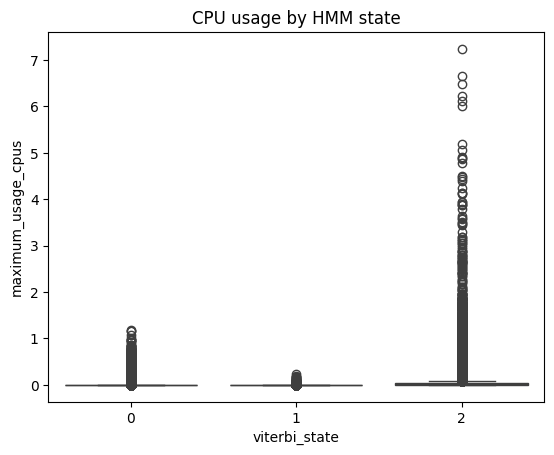

In [86]:
sns.boxplot(data=train_df, x="viterbi_state", y="maximum_usage_cpus")
plt.title("CPU usage by HMM state")
plt.show()

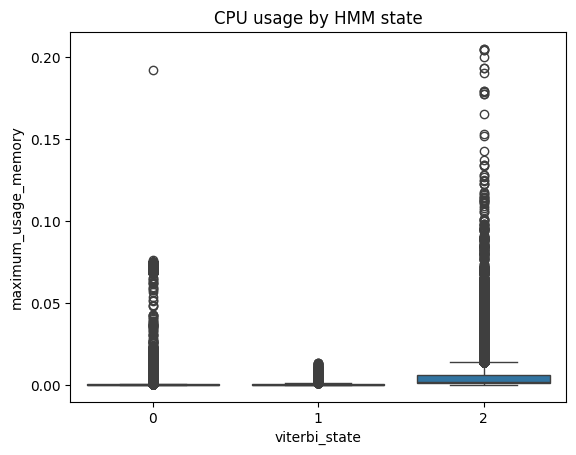

In [87]:
sns.boxplot(data=train_df, x="viterbi_state", y="maximum_usage_memory")
plt.title("CPU usage by HMM state")
plt.show()

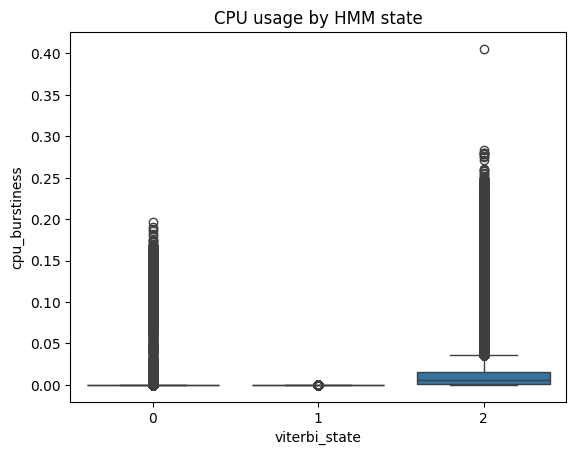

In [88]:
sns.boxplot(data=train_df, x="viterbi_state", y="cpu_burstiness")
plt.title("CPU usage by HMM state")
plt.show()

In [89]:
# State separation (ANOVA / effect size)
# Features that vary a lot across states are useful.
# Large F (small p) → keep.


for f in feature_set:
    groups = [train_df[train_df["viterbi_state"]==s][f] for s in sorted(train_df["viterbi_state"].dropna().unique())]
    F, p = f_oneway(*groups)
    print(f, F, p)

average_usage_cpus_logged_normed 2657147.5392878 0.0
cpu_p90_logged_normed 5993445.811578425 0.0
average_usage_memory_logged_normed 1486769.3354958333 0.0
assigned_memory_logged_normed 239390.17103782564 0.0
cpu_burstiness_logged_normed 6922464.269029262 0.0


In [90]:
# PCA loadings (redundancy check)
# See which features actually drive variance.
# Low loadings across PCs → candidate to drop.

X = StandardScaler().fit_transform(train_df[feature_set].dropna())
pca = PCA().fit(X)
pd.Series(pca.components_[0], index=feature_set).sort_values(key=abs, ascending=False)

,0
cpu_burstiness_logged_normed,0.502413
average_usage_cpus_logged_normed,0.498725
cpu_p90_logged_normed,0.498107
average_usage_memory_logged_normed,0.465187
assigned_memory_logged_normed,0.185326


In [91]:
# Kill prediction importance (simple model)
# Even though HMM is unsupervised, you can check which features predict kill_row.
# Higher importance → keep.

X = train_df[feature_set].fillna(0)
y = train_df["kill_row"]

rf = RandomForestClassifier(n_estimators=200).fit(X, y)
pd.Series(rf.feature_importances_, index=feature_set).sort_values(ascending=False)

,0
average_usage_cpus_logged_normed,0.277273
average_usage_memory_logged_normed,0.258194
assigned_memory_logged_normed,0.170561
cpu_p90_logged_normed,0.156669
cpu_burstiness_logged_normed,0.137303


chatgpt suggestion for best features for high correlation, high robustness, high variance

average_usage_cpus_logged_normed
cpu_p90_logged_normed
average_usage_memory_logged_normed
assigned_memory_logged_normed
cpu_burstiness_logged_normed

In [92]:
model = {
    "pi": pi_np,
    "A": A_np,
    "mu": mu_np,
    "sigma": sg_np,
    "features": feature_set,
    "K": K,
    "norm_params": norm_params
}

In [93]:
# file_path = "/content/drive/MyDrive/Bayesian Final Project/DATA/hmm_model_march11v2.pkl"

# with open(file_path, "wb") as f:
   # pickle.dump(model, f)

In [94]:
df_last1 = train_df[train_df["last_event"] == 1]

top_combo = (
    df_last1
    .groupby(["collection_id", "instance_index"])
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
)

top_combo.head(10)

,collection_id,instance_index,row_count
2,259837260882,1,97593
3,259837769991,0,67259
7,319964021873,2,66760
6,319964021873,1,66651
10,350880622464,0,49762
4,280521931310,2,27453
5,300125039260,0,27381
17,374709148602,2,17549
9,350084572141,3,16701
49,381007811951,1,13337


In [95]:
train_df.loc[train_df['last_event'] == 1] \
    .groupby(['collection_id', 'instance_index']) \
    .size() \
    .reset_index(name='count') \
    .sort_values('count', ascending=False)
# df.loc[df['collection_id'] == 374860314079, 'last_event'].value_counts()

,collection_id,instance_index,count
2,259837260882,1,97593
3,259837769991,0,67259
7,319964021873,2,66760
6,319964021873,1,66651
10,350880622464,0,49762
...,...,...,...
57,382975382187,2476,6
76,396080657133,5176,5
29,376743646216,248,4
37,378749911194,161,4


In [96]:
# ---- pick the sequence ----
cid_target = 350880622464	 #113812359317
iid_target = 0

seq_df = train_df[
    (train_df["collection_id"] == cid_target) &
    (train_df["instance_index"] == iid_target)
].copy()

seq_df = seq_df.sort_values("start_time").reset_index(drop=True)

# ---- choose the 3 forward-probability columns ----
state_cols = ["hmm_state_0_prob", "hmm_state_1_prob", "hmm_state_2_prob"]

# dominant state per row = highest probability state
seq_df["dominant_state"] = seq_df[state_cols].to_numpy().argmax(axis=1)

# optional: convert time to relative time for easier plotting
seq_df["time_rel"] = seq_df["start_time"] - seq_df["start_time"].min()

print(seq_df[["start_time", "time_rel", "average_usage_cpus", *state_cols, "dominant_state"]].head())
print("Number of rows in sequence:", len(seq_df))

   start_time   time_rel  average_usage_cpus  hmm_state_0_prob  \
0   623000000          0            0.003212          0.000165   
1   648000000   25000000            0.000000          0.533610   
2   650000000   27000000            0.000000          0.075419   
3   776000000  153000000            0.000000          0.036400   
4   778000000  155000000            0.003887          0.000076   

   hmm_state_1_prob  hmm_state_2_prob  dominant_state  
0      2.719657e-09      9.998346e-01               2  
1      4.663899e-01      6.950507e-17               0  
2      9.245810e-01      3.379817e-18               1  
3      9.635996e-01      1.377316e-28               1  
4      1.156483e-09      9.999239e-01               2  
Number of rows in sequence: 49762


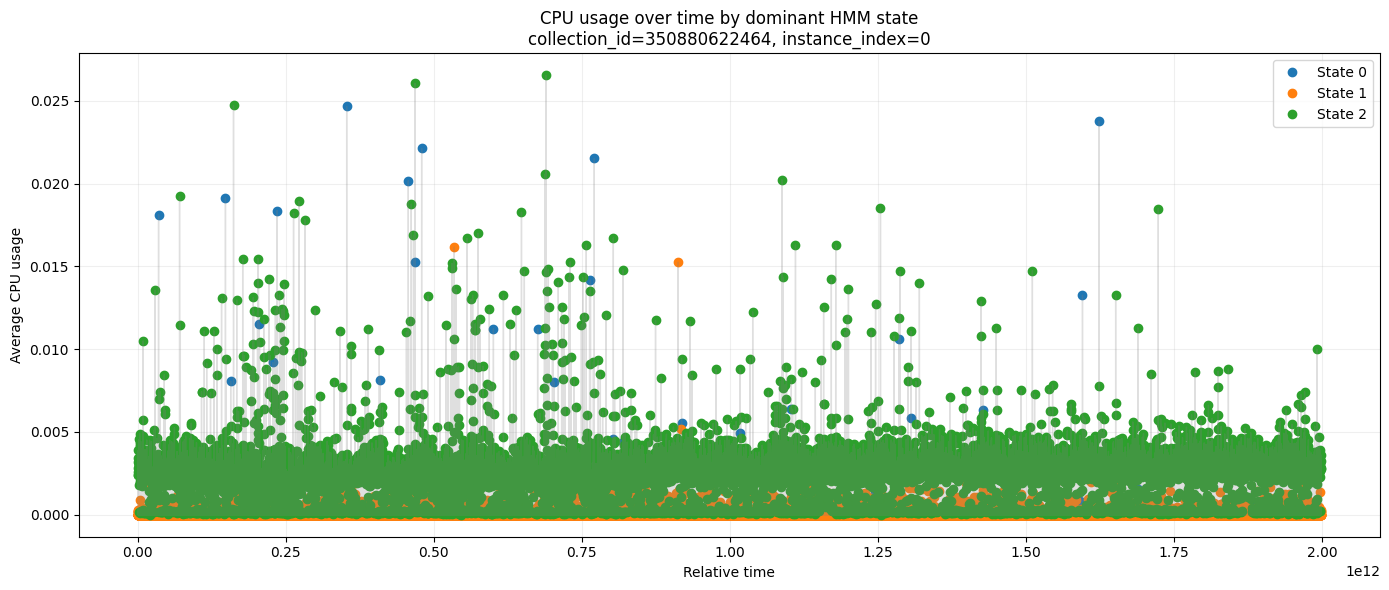

In [97]:
plt.figure(figsize=(14, 6))

# colored line segments
for k in range(3):
    mask = seq_df["dominant_state"] == k
    plt.plot(
        seq_df.loc[mask, "time_rel"],
        seq_df.loc[mask, "average_usage_cpus"],
        marker="o",
        linestyle="None",
        label=f"State {k}"
    )

# faint full trajectory underneath
plt.plot(
    seq_df["time_rel"],
    seq_df["average_usage_cpus"],
    color="gray",
    alpha=0.25,
    linewidth=1
)

plt.xlabel("Relative time")
plt.ylabel("Average CPU usage")
plt.title(f"CPU usage over time by dominant HMM state\ncollection_id={cid_target}, instance_index={iid_target}")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [98]:
seq_df = train_df[
    (train_df["collection_id"] == cid_target) &
    (train_df["instance_index"] == iid_target)
].copy()

# determine dominant state for each row
state_cols = ["hmm_state_0_prob", "hmm_state_1_prob", "hmm_state_2_prob"]
seq_df["dominant_state"] = seq_df[state_cols].to_numpy().argmax(axis=1)

# count rows in each state
state_counts = seq_df["dominant_state"].value_counts().sort_index()

# convert to percentages
state_percent = state_counts / len(seq_df) * 100

print("Row counts by state:")
print(state_counts)

print("\nPercentage of rows in each state:")
print(state_percent.round(2))

Row counts by state:
dominant_state
0     1500
1    34687
2    13575
Name: count, dtype: int64

Percentage of rows in each state:
dominant_state
0     3.01
1    69.71
2    27.28
Name: count, dtype: float64


In [99]:
import numpy as np

K = len(pi_np)   # number of states

all_states = np.concatenate(train_z_paths)

counts = np.bincount(all_states, minlength=K)
percentages = counts / counts.sum()

for k in range(K):
    print(f"State {k}: {percentages[k]*100:.2f}%")

State 0: 5.79%
State 1: 16.98%
State 2: 77.23%
